E-commerce Customer Segmentation System

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv("smartcart_customers.csv")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0


In [3]:
df.shape

(2240, 22)

In [4]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [5]:
### Data Pre-Processing

In [6]:
# Handling missing values

df["Income"] = df["Income"].fillna(df["Income"].median())

In [7]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0


In [8]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

In [9]:
### Feature Engineering

In [10]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response'],
      dtype='str')

In [11]:
# age

df["Age"] = 2026 - df["Year_Birth"]
df.head(3)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,61


In [12]:
# Customer Joining Date

df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst=True)

reference_date = df["Dt_Customer"].max()

df["Customer_Tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days

In [13]:
df.head(3)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,61,312


In [14]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days'],
      dtype='str')

In [15]:
# Total Spending

df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [16]:
df.head(3)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,1,69,663,1617
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,72,113,27
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,61,312,776


In [17]:
# Total children

df["Total_children"] = df["Kidhome"] + df["Teenhome"]

In [18]:
df.head(3)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,61,312,776,0


In [19]:
# Education

df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [20]:
# undergraduate , Graduate , Postgraduate

df["Education"] = df["Education"].replace(
    {
        "Basic":"Undergraduate", "2n Cycle": "Undergraduate",
        "Graduation" : "Graduate" ,
        "Master" : "Postgraduation" , "PhD" : "Postgraduation"  
    }
)

In [21]:
df["Education"].value_counts()

Education
Graduate          1127
Postgraduation     856
Undergraduate      257
Name: count, dtype: int64

In [22]:
# Marital Status

In [23]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [24]:
df["Living_With"] = df["Marital_Status"].replace(
    {
        "Married":"Partener", "Together": "Partener",
        "Single" : "Alone" ,  "Divorced" : "Alone" ,"Absurd" : "Alone" ,"Widow" : "Alone" ,"YOLO" : "Alone" ,
    }
)

In [25]:
df["Living_With"].value_counts()

Living_With
Partener    1444
Alone        796
Name: count, dtype: int64

In [26]:
# Drop Unnecesary Columns

In [27]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days', 'Total_Spending',
       'Total_children', 'Living_With'],
      dtype='str')

In [28]:
cols = ["ID", "Year_Birth" , "Marital_Status" , "Kidhome" , "Teenhome" ,"Dt_Customer" ,"MntWines" ,"MntFruits" ,"MntMeatProducts" ,"MntFishProducts" ,"MntSweetProducts" ,"MntGoldProds"]

df_cleaned = df.drop(columns=cols)

In [29]:
df_cleaned.shape

(2240, 15)

In [30]:
df_cleaned.head(3)

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partener


In [31]:
# Outliers

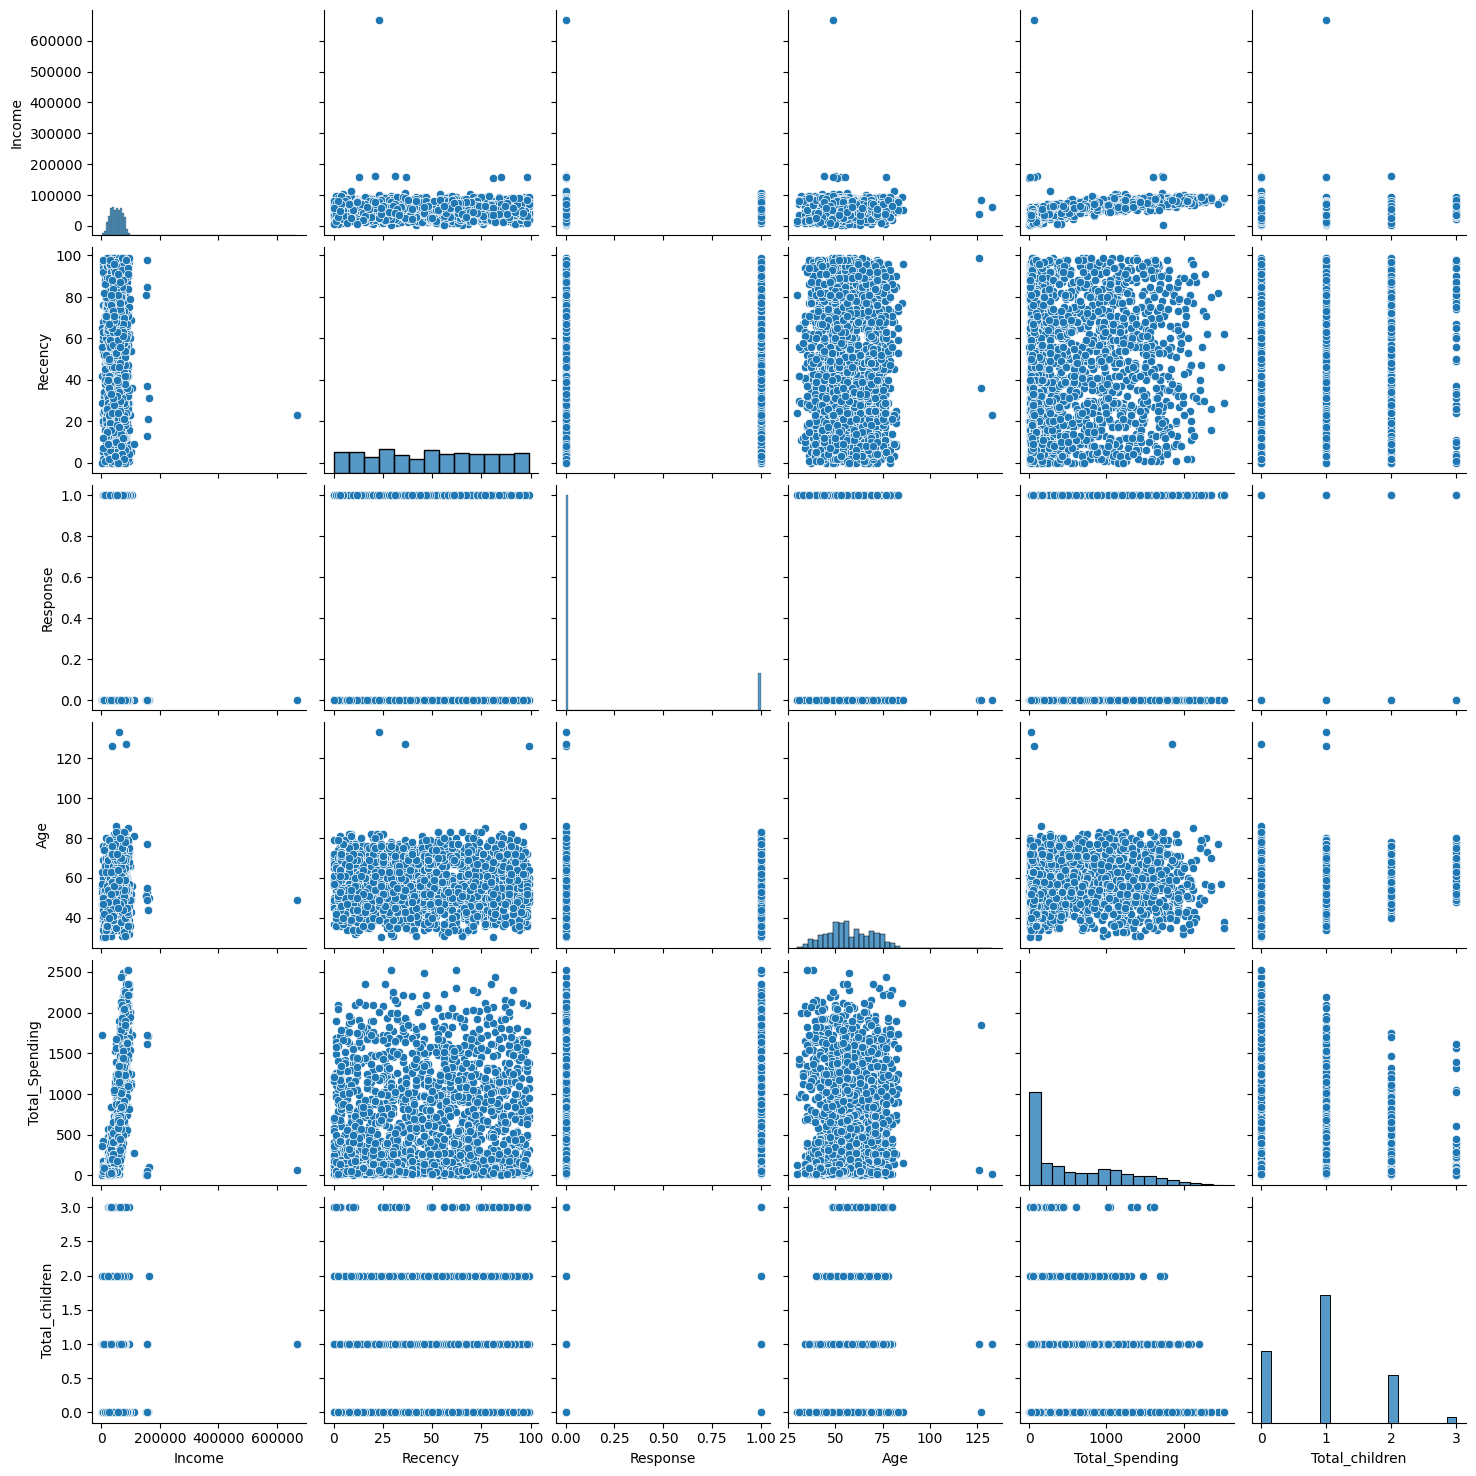

In [32]:
cols = ["Income","Recency" ,"Response" ,"Age" ,"Total_Spending" ,"Total_children"]

# relative plots of some features - pair plots

sns.pairplot(df_cleaned[cols])

In [33]:
# Remove the outliers

print(f"data size with outliers : {len(df_cleaned)}")

df_cleaned = df_cleaned[ (df_cleaned["Age"]<90)]

df_cleaned = df_cleaned[ (df_cleaned["Income"]<600_000)]

print(f"data size without outliers : {len(df_cleaned)}")

data size with outliers : 2240
data size without outliers : 2236


In [34]:
# Correlation - Heatmaps

<Axes: >

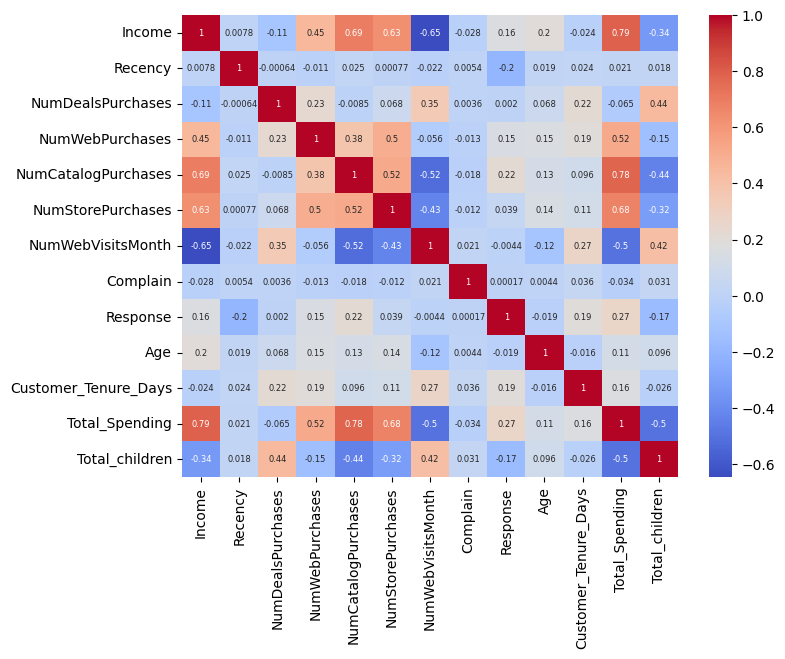

In [35]:
corr = df_cleaned.corr(numeric_only=True)

plt.figure(figsize=(8,6))
plt.tight_layout()
sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},
    cmap = "coolwarm"
)

In [36]:
df_cleaned.shape

(2236, 15)

In [37]:
# Encoding

In [38]:
from sklearn.preprocessing import OneHotEncoder

In [39]:
cat_cols = ["Education","Living_With"]

ohe = OneHotEncoder()

enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

enc_df = pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index=df_cleaned.index)

In [40]:
enc_df.head(3)

,Education_Graduate,Education_Postgraduation,Education_Undergraduate,Living_With_Alone,Living_With_Partener
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0


In [41]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols) , enc_df] , axis = 1)

In [42]:
df_encoded.shape

(2236, 18)

In [43]:
df_encoded.head(3)

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_children,Education_Graduate,Education_Postgraduation,Education_Undergraduate,Living_With_Alone,Living_With_Partener
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0


In [44]:
df_cleaned.head(3)

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partener


In [45]:
# Scaling

In [46]:
from sklearn.preprocessing import StandardScaler

In [47]:
X = df_encoded

In [48]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [49]:
# Visualize

In [50]:
X_scaled.shape

(2236, 18)

In [51]:
# 2D Visualization

In [52]:
from sklearn.decomposition import PCA 

In [53]:
pca = PCA(
    n_components=3,
)

In [54]:
x_pca = pca.fit_transform(X_scaled)

c:\Users\ohhaa\OneDrive\Desktop\AIML\sklearn-env\Lib\site-packages\matplotlib\collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


Text(0.5, 0.92, '3D Projection')

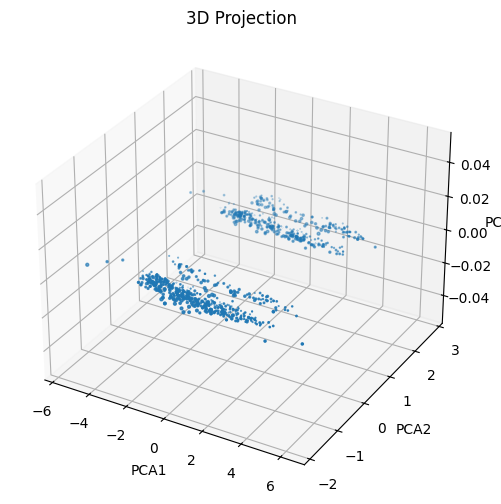

In [55]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111,projection="3d")

plt.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D Projection")

In [56]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

In [57]:
## Analyze K value

In [58]:
# 1. Elbow Method

from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []

for k in range(1,11):

    kmeans = KMeans(n_clusters=k , random_state=42)
    kmeans.fit_predict(x_pca)
    wcss.append(kmeans.inertia_)

In [59]:
knee = KneeLocator(range(1,11),wcss , curve="convex" , direction="decreasing" )

optimal_k = knee.elbow

print(f"Best k : {optimal_k}")

Best k : 4


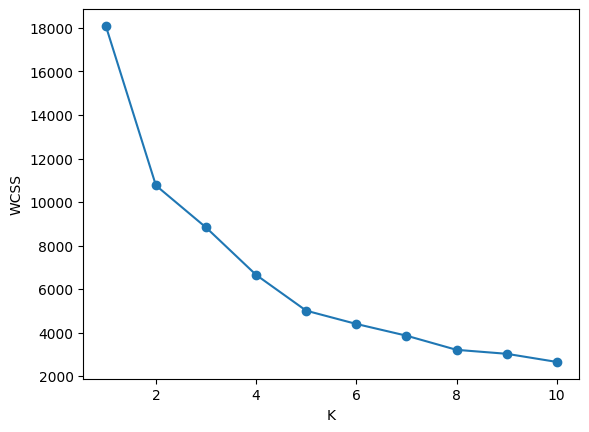

In [61]:
# plot 

plt.plot(range(1,11) , wcss, marker = 'o')
plt.xlabel("K")
plt.ylabel("WCSS")
plt.show()

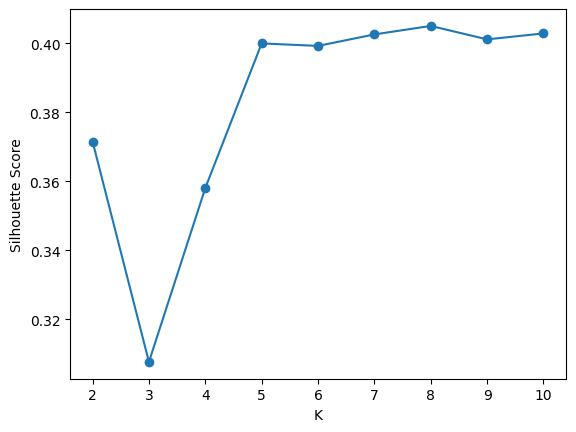

In [62]:
# 2. Silhouette Score 

from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k , random_state=42)
    labels = kmeans.fit_predict(x_pca)
    score = silhouette_score(x_pca,labels)
    scores.append(score)


## plot 
plt.plot(range(2,11) , scores, marker = 'o')
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.show()

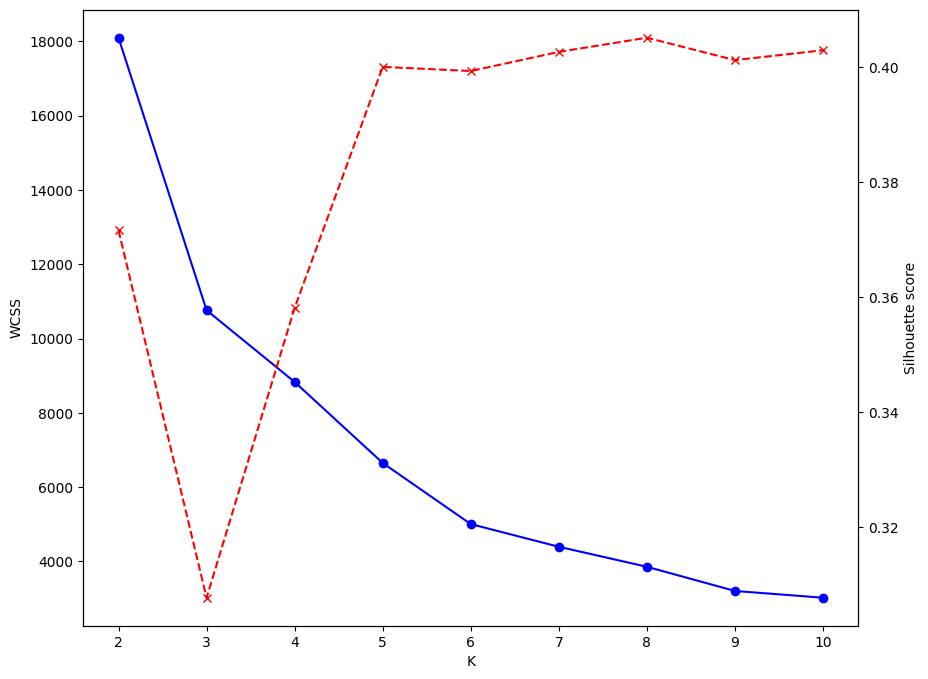

In [67]:
# combined plot 

k_range = range(2,11)

fig, ax1 = plt.subplots(figsize=(10,8))

ax1.plot(k_range , wcss[:len(k_range)], marker = 'o' , color = 'blue')
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")


ax2 = ax1.twinx()
ax2.plot(k_range , scores[:len(k_range)] , marker='x' , color = 'red' , linestyle = '--')
ax2.set_ylabel("Silhouette score")

plt.show()


In [ ]:
# Clustering

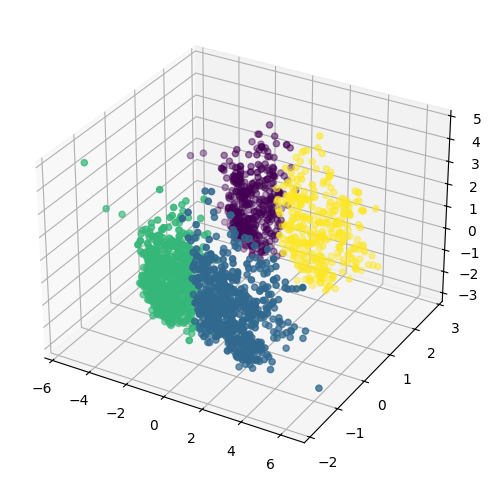

In [70]:
# K_Means

kmeans = KMeans(n_clusters=4 , random_state=4)

labels_kmeans = kmeans.fit_predict(x_pca)

fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111,projection="3d")

ax.scatter(x_pca[:,0] , x_pca[:,1] , x_pca[:,2] , c = labels_kmeans)



In [71]:
# Agglomerative Clustering

from sklearn.cluster import AgglomerativeClustering

agg_clf = AgglomerativeClustering( n_clusters=4 , linkage="ward" )

In [72]:
labels_agg_clf = agg_clf.fit_predict(x_pca)

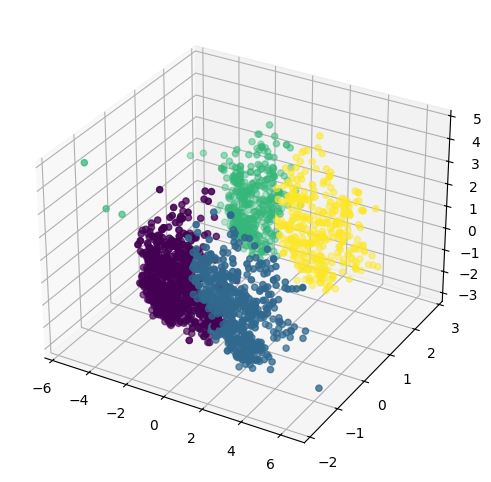

In [73]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111,projection="3d")

ax.scatter(x_pca[:,0] ,x_pca[:,1] , x_pca[:,2], c = labels_agg_clf)

In [ ]:
# characterization of clusters

In [79]:
X["labels"] = labels_agg_clf
X.head(5)

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_children,Education_Graduate,Education_Postgraduation,Education_Undergraduate,Living_With_Alone,Living_With_Partener,labels
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='labels', ylabel='count'>

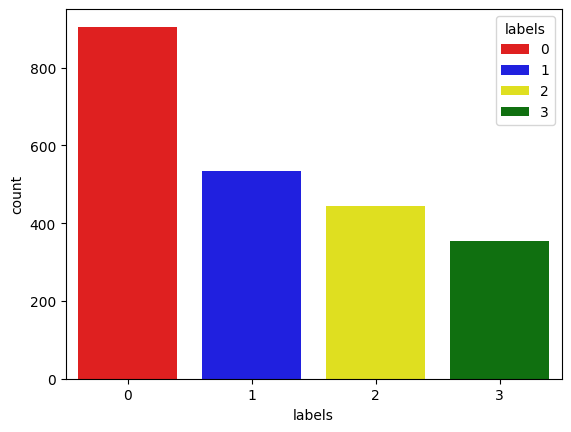

In [80]:
pal = [ "red" , "blue" , "yellow" ,"green" ]
sns.countplot(x = X["labels"] , palette=pal , hue = X["labels"])

In [ ]:
# Income & Spending Patterns

<Axes: xlabel='Total_Spending', ylabel='Income'>

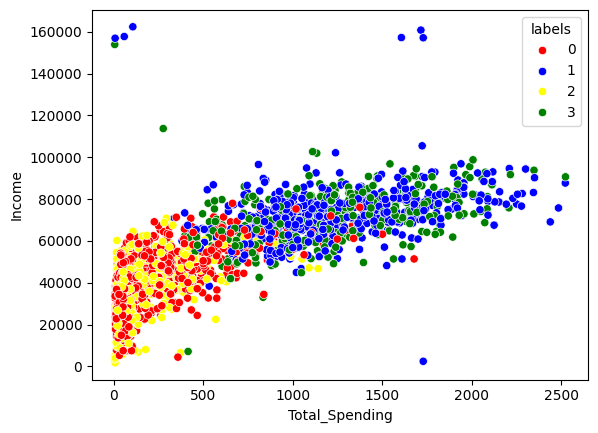

In [81]:
sns.scatterplot(x=X["Total_Spending"] , y = X["Income"] , hue = X["labels"] , palette=pal)

In [83]:
# cluster summary 

cluster_summary = X.groupby("labels").mean()

print(f"Cluster Summary : {cluster_summary}")

Cluster Summary :               Income    Recency  ...  Living_With_Alone  Living_With_Partener
labels                           ...                                         
0       39680.580110  48.914917  ...           0.000000              1.000000
1       72808.445693  49.202247  ...           0.000000              1.000000
2       36960.143018  48.319820  ...           0.993243              0.006757
3       70722.681303  50.504249  ...           1.000000              0.000000

[4 rows x 18 columns]
